# Tokenization Study

## Datasets: Loading and Cleaning

### Itihasa

In [ ]:
import requests

url = "https://raw.githubusercontent.com/rahular/itihasa/main/data/dev.sn"

data = requests.get(url).text.splitlines()

In [ ]:
data[:2]

In [ ]:
# searching for Sandhis: This just means that this dataset has sandhis and is not a disolved dataset.

matches = [line for line in data if "ऽ" in line]

print(len(matches))
print(matches[0])

In [ ]:
# Corpus Statistics:


def corpus_statistics(data):
  """
  corpus statistics
  """

# Calculate metrics for the dataset
  num_verses = num_verses = len(data)

# Calculate num_lines by counting ' । ' and ' ॥ ' delimiters
  num_lines = 0
  for sentence in data:
    num_lines += sentence.count('।')
    num_lines += sentence.count('॥')


  total_characters = sum(len(sentence.replace(' ', '')) for sentence in data)
  total_words = sum(len(sentence.split()) for sentence in data)

  print(f"Number of verses: {num_verses}")
  print(f"Number of lines: {num_lines}")
  print(f"Total characters (excluding spaces): {total_characters}")
  print(f"Total words: {total_words}")

  # Calculate averages
  average_words_per_verse = total_words / num_verses
  average_chars_per_verse = total_characters / num_verses
  average_words_per_line = total_words / num_lines
  average_chars_per_line = total_characters / num_lines

  print(f"\n")
  print(f"Average words per verse: {average_words_per_verse:.2f}")
  print(f"Average characters per verse: {average_chars_per_verse:.2f}")
  print(f"Average words per line: {average_words_per_line:.2f}")
  print(f"Average characters per line: {average_chars_per_line:.2f}")

In [ ]:
corpus_statistics(data)

### Data Cleaning

Going through all the unicode letters and determining any anomilities:

In [ ]:
import unicodedata

unique_chars = sorted(set("".join(data)))

for ch in unique_chars:
    print(
        repr(ch),
        hex(ord(ch)),
        unicodedata.name(ch, "UNKNOWN")
    )

I] Punctuation:

Traditional Sanskrit manuscripts generally do not contain modern punctuation marks. Therefore, the following symbols could be removed during preprocessing:

'!' 0x21 EXCLAMATION MARK

'(' 0x28 LEFT PARENTHESIS

')' 0x29 RIGHT PARENTHESIS

',' 0x2c COMMA

'-' 0x2d HYPHEN-MINUS

'?' 0x3f QUESTION MARK

'[' 0x5b LEFT SQUARE BRACKET

'_' 0x5f LOW LINE

'—' 0x2014 EM DASH

'‘' 0x2018 LEFT SINGLE QUOTATION MARK

'”' 0x201d RIGHT DOUBLE QUOTATION MARK

'•' 0x2022 BULLET

However, for training a Sanskrit language model, retaining such punctuation may be beneficial because modern digital Sanskrit texts frequently contain these symbols as they are used in everyday nuances.


II] Non-Standard Sanskrit Characters and OCR Artifacts:

The below charachters are definitely not part of standard sanskrit and OCR errors:

'़' 0x93c DEVANAGARI SIGN NUKTA

'ॅ' 0x945 DEVANAGARI VOWEL SIGN CANDRA E

'॑' 0x951 DEVANAGARI STRESS SIGN UDATTA

'॒' 0x952 DEVANAGARI STRESS SIGN ANUDATTA

'ā' 0x101 LATIN SMALL LETTER A WITH MACRON

"'" 0x27 APOSTROPHE

While nukta and anudatta/ udatta are part of vedic sanskrit, they are not a part of standard sanskrit. Since this study focuses on Classical Sanskrit tokenization, these characters are removed.


III] Manual Inspection of Rare Characters

'क़' 0x958 DEVANAGARI LETTER QA

'ऱ' 0x931 DEVANAGARI LETTER RRA

These letters are primarily associated with Hindi and Urdu orthography. Their occurrences in the corpus were manually inspected. As each character occurred only once and was determined to be an OCR or transcription error, it was replaced with its appropriate Sanskrit counterpart.

IV] Character Normalization

The following normalizations were applied:

'.' (U+002E) FULL STOP → '।' (U+0964) DEVANAGARI DANDA

'ॊ' (U+094A) DEVANAGARI VOWEL SIGN SHORT O → 'ो' (U+094B) DEVANAGARI VOWEL SIGN O

In [ ]:
for text in data:
    for word in text.split():
        if "ऱ" in word:
            print(word)

In [ ]:
for text in data:
    if "ऱ" in text:
        print(text.replace("ऱ", "[ऱ]"))

In [ ]:
for text in data:
  if "क़" in text:
    print(text)

In [ ]:
import re

# Characters to normalize
REPLACE_MAP = str.maketrans({
    "क़": "क",
    "ऱ": "र",
    "ॊ": "ो",
    ".": "।"
})

# Characters to remove
REMOVE_CHARS = str.maketrans('','',"़ॅ॒॑ā'!(),-?[_—‘”•")

def clean_text(corpus: list):

    cleaned_texts = []

    for sentence in corpus:

        if not isinstance(sentence, str):
            continue

        sentence = sentence.strip()

        # Normalize characters
        sentence = sentence.translate(REPLACE_MAP)

        # Remove unwanted characters
        sentence = sentence.translate(REMOVE_CHARS)

        # Separate Sanskrit punctuation
        sentence = re.sub(r"॥", " ॥ ", sentence)
        sentence = re.sub(r"।", " । ", sentence)

        # Normalize whitespace
        sentence = re.sub(r"\s+", " ", sentence).strip()

        # Skip empty sentences
        if sentence:
            cleaned_texts.append(sentence)

    return cleaned_texts

In [ ]:
data = clean_text(data)
data[:2]

In [ ]:
for text in data:
  if "क़" in text:
    print(text)

In [ ]:
corpus_statistics(data)

### Word Distribution

In [ ]:
words = []

for sentence in data:
    words.extend(sentence.split())

longest_word = max(words, key=len)

print("Longest word:")
print(longest_word)

print("\nLength:")
print(len(longest_word))

In [ ]:
import regex

def lenghth_shabda(text):

    aksharas = regex.findall(
        r'[अ-हॐ][ािीुूृॄॢॣेैोौ]?ं?ः?',
        text
    )

    return len(aksharas)

word = longest_word

print(lenghth_shabda(word))

In [ ]:
unique_words = set(words)

longest_words = sorted(
    unique_words,
    key=len,
    reverse=True
)

for w in longest_words[:5]:
    print(lenghth_shabda(w), w)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

word_lengths = [lenghth_shabda(word) for word in words if lenghth_shabda(word) > 0]

# filtered = [x for x in word_lengths if x <= 25]
filtered = [x for x in word_lengths]

plt.figure(figsize=(8,5))

plt.hist(
    filtered,
    bins=20,
    density=True,
    alpha=0.5,
    edgecolor="black"
)

x = np.linspace(min(filtered), max(filtered), 500)
kde = gaussian_kde(filtered)

plt.plot(x, kde(x), linewidth=2)

plt.xlabel("Word Length (characters)")
plt.ylabel("Density")
plt.title("Word Length Distribution")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

filtered = [x for x in word_lengths if x <= 25]

plt.figure(figsize=(8,5))

plt.hist(
    filtered,
    bins=20,
    density=True,
    alpha=0.5,
    edgecolor="black"
)

x = np.linspace(min(filtered), max(filtered), 500)
kde = gaussian_kde(filtered)

plt.plot(x, kde(x), linewidth=2)

plt.xlabel("Word Length (characters)")
plt.ylabel("Density")
plt.title("Word Length Distribution (Words ≤ 25 Characters)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(
    word_lengths,
    vert=False
)

plt.xlabel("Word Length (characters)")
plt.title("Word Length Distribution with Outliers")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

print("Average word lenths:", np.mean(word_lengths))
print("Median:", np.median(word_lengths))
print("25th percentile:", np.percentile(word_lengths, 25))
print("75th percentile:", np.percentile(word_lengths, 75))
print("95th percentile:", np.percentile(word_lengths, 95))
print("99th percentile:", np.percentile(word_lengths, 99))
print("Maximum:", max(word_lengths))
print("Minimum:", min(word_lengths))

## Loading the tokenizers

### GPT Tokenizers for old and new

In [21]:
# they live in the tiktoken environmemt, and here i can use the name as tokenizers using .encode:

import tiktoken
gpt_enc = tiktoken.get_encoding("cl100k_base")
o200k_enc = tiktoken.get_encoding("o200k_base")

### SentencePiece

As used by (Kumar, 2026)

In [22]:
import requests
!wget https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/sentencepiece/spm_sa.model

--2026-06-02 06:55:02--  https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/sentencepiece/spm_sa.model
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 448781 (438K) [application/octet-stream]
Saving to: ‘spm_sa.model’

spm_sa.model        100%[===================>] 438.26K  --.-KB/s    in 0.02s   

2026-06-02 06:55:02 (18.6 MB/s) - ‘spm_sa.model’ saved [448781/448781]



In [23]:
import sentencepiece as spm
from pathlib import Path

def load_spm(lang: str) -> spm.SentencePieceProcessor:
    sp = spm.SentencePieceProcessor()
    sp.load("spm_sa.model")
    return sp

In [24]:
sp_sa = load_spm("sa")

### SansGPT Tokenizer

In [25]:
!wget https://raw.githubusercontent.com/rhugvedd/SansGPT-Advancing-Generative-Pre-Training-in-Sanskrit/master/BPETokenizer.py
!wget https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/SansGPT/Final-Corpus-Tokenizer-Merge-Info-NL-12000-.pkl
!wget https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/SansGPT/Final-Corpus-Tokenizer-Vocab-NL-12000-.pkl

--2026-06-02 06:55:03--  https://raw.githubusercontent.com/rhugvedd/SansGPT-Advancing-Generative-Pre-Training-in-Sanskrit/master/BPETokenizer.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22017 (22K) [text/plain]
Saving to: ‘BPETokenizer.py’

BPETokenizer.py     100%[===================>]  21.50K  --.-KB/s    in 0.001s  

2026-06-02 06:55:03 (14.1 MB/s) - ‘BPETokenizer.py’ saved [22017/22017]

--2026-06-02 06:55:03--  https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/SansGPT/Final-Corpus-Tokenizer-Merge-Info-NL-12000-.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133

In [26]:
vocab_path = "./"
merge_info_name = "Final-Corpus-Tokenizer-Merge-Info-NL-12000-"
vocab_name = "Final-Corpus-Tokenizer-Vocab-NL-12000-"

In [27]:
# SansGPT BPE Tokenizer:
# as implemented in paper

from BPETokenizer import BPETokenizer

Tokenizer = BPETokenizer()
Tokenizer.load(vocab_path, merge_info_name, vocab_name)

Loaded Vocabulary!
Vocab Size: 12000
MergeInfo Size: 11744


In [28]:
dir(Tokenizer)

['Decode',
 'DecodeVocab',
 'Encode',
 'EncodeFromText',
 'GetBigramStats',
 'GetCleanedText',
 'Merge',
 'MergeInfo',
 'PrintTokenizedText',
 'TrainVocab',
 'TrainVocab_fromText',
 'Vocab',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'count_bigrams',
 'load',
 'save',
 'special_tok',
 'special_tokens']

### Sutra

In [29]:
from google.colab import userdata
from huggingface_hub import login
from transformers import AutoTokenizer

login(userdata.get("HF_TOKEN"))

In [30]:
sutra = AutoTokenizer.from_pretrained("TWO/sutra-mlt256-v2")

tokenizer_config.json:   0%|          | 0.00/12.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/12.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.95k [00:00<?, ?B/s]

### HF tokenizers

In [31]:
from transformers import AutoTokenizer

claude = AutoTokenizer.from_pretrained("Xenova/claude-tokenizer")
tiny = AutoTokenizer.from_pretrained("openaccess-ai-collective/tiny-mistral")
sutra = AutoTokenizer.from_pretrained("TWO/sutra-mlt256-v2")
qwen_sanskrit_model = AutoTokenizer.from_pretrained("diabolic6045/Sanskrit-Qwen2.5-7B-base")
qwen_sanskrit_tokenizer = AutoTokenizer.from_pretrained("diabolic6045/Sanskrit-English-qwen2-tokenizer")
mt5 = AutoTokenizer.from_pretrained("google/mt5-small")
mbart = AutoTokenizer.from_pretrained("facebook/mbart-large-50")
airavata = AutoTokenizer.from_pretrained("ai4bharat/Airavata") # needs login
llama = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct") # needs login # access granted
aya = AutoTokenizer.from_pretrained("CohereLabs/aya-expanse-8b") # needs login
gemma = AutoTokenizer.from_pretrained("google/gemma-1.1-2b-it") # needs login

tokenizer_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.77M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/626 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/963 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/618 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/34.2k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

## Metadata Tokenizers

In [32]:
import pandas as pd


def tokenizer_metadata_table(tokenizers_dict):

    rows = []

    for label, tok in tokenizers_dict.items():

        row = {
            "label": label,
            "class": getattr(tok, "backend_model", type(tok).__name__),
        }

        # -----------------------------
        # vocab size
        # -----------------------------

        if hasattr(tok, "vocab_size"):
          vocab = tok.vocab_size

          if callable(vocab):
            row["vocab_size"] = vocab()
          else:
            row["vocab_size"] = vocab

        elif hasattr(tok, "n_vocab"):

          row["vocab_size"] = tok.n_vocab

        elif hasattr(tok, "Vocab"):
          try:
            row["vocab_size"] = len(tok.Vocab)
          except:
            row["vocab_size"] = "not available"

        else:

          row["vocab_size"] = "not available"

        # -----------------------------
        # model path / tokenizer name
        # -----------------------------
        if hasattr(tok, "name_or_path"):

            row["model_path"] = tok.name_or_path

        elif hasattr(tok, "name"):

            row["model_path"] = tok.name

        elif hasattr(tok, "MergeInfo"):
          row["model_path"] = tok.__class__.__name__

        else:

            row["model_path"] = "not available"


        # -----------------------------
        # backend tokenizer model
        # -----------------------------
        try:

            row["backend_model"] = str(tok.backend_tokenizer.model)

        except:
          if hasattr(tok, "backend_model"):
            row["backend_model"] = tok.backend_model

          else:
            row["backend_model"] = tok.__class__.__name__


        # -----------------------------
        # special tokens
        # -----------------------------
        try:

            row["special_tokens"] = tok.special_tokens_map

        except:
          if hasattr(tok, "special_tokens"):
            row["special_tokens"] = tok.special_tokens

          elif hasattr(tok, "special_tok"):
            row["special_tokens"] = tok.special_tok

          else:
            try:
              row["special_tokens"] = tok._special_tokens
            except:
              row["special_tokens"] = "not available"

        # -----------------------------
        # sentencepiece model
        # -----------------------------

        if type(tok).__name__ == "SentencePieceProcessor":
          row["model_path"] = getattr(tok, "_model_file", "SentencePiece Model")
          row["backend_model"] = type(tok).__name__

          try:
            row["special_tokens"] = {
                "unk_id": tok.unk_id(),
                "bos_id": tok.bos_id(),
                "eos_id": tok.eos_id(),
                "pad_id": tok.pad_id()
                }
          except:
            row["special_tokens"] = "not available"

        rows.append(row)

    meta_df = pd.DataFrame(rows)

    return meta_df

In [33]:
tokenizers = {

    "claude": claude,
    "tiny_mistral": tiny,
    "sutra": sutra,
    "qwen_sanskrit_model": qwen_sanskrit_model,
    "qwen_sanskrit_tokenizer": qwen_sanskrit_tokenizer,
    "mt5": mt5,
    "mbart": mbart,
    "airavata" : airavata, # needs login
    "llama": llama, # needs login # access granted
    "aya": aya, # needs login
    "gemma": gemma, # needs login
    "cl100k_base": gpt_enc,
    "o200k_base": o200k_enc,
    "sentencepiece_sa": sp_sa,
    "sansgpt_tokenizer": Tokenizer
}

meta_df = tokenizer_metadata_table(tokenizers)

meta_df

,label,class,vocab_size,model_path,backend_model,special_tokens
0,claude,GPT2Tokenizer,65000,Xenova/claude-tokenizer,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<EOT>', 'eos_token': '<EOT>', '..."
1,tiny_mistral,TokenizersBackend,32000,openaccess-ai-collective/tiny-mistral,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
2,sutra,TokenizersBackend,256001,TWO/sutra-mlt256-v2,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
3,qwen_sanskrit_model,Qwen2Tokenizer,151643,diabolic6045/Sanskrit-Qwen2.5-7B-base,"BPE(dropout=None, unk_token=None, continuing_s...","{'eos_token': '<|endoftext|>', 'pad_token': '<..."
4,qwen_sanskrit_tokenizer,TokenizersBackend,120000,diabolic6045/Sanskrit-English-qwen2-tokenizer,"BPE(dropout=None, unk_token=None, continuing_s...","{'eos_token': '<|im_end|>', 'unk_token': '<unk..."
5,mt5,T5Tokenizer,250100,google/mt5-small,"Unigram(unk_id=2, vocab=[(""<pad>"", 0), (""</s>""...","{'eos_token': '</s>', 'unk_token': '<unk>', 'p..."
6,mbart,MBart50Tokenizer,250054,facebook/mbart-large-50,"Unigram(unk_id=3, vocab=[(""<s>"", 0), (""<pad>"",...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
7,airavata,TokenizersBackend,48064,ai4bharat/Airavata,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
8,llama,TokenizersBackend,128000,meta-llama/Llama-3.1-8B-Instruct,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<|begin_of_text|>', 'eos_token'..."
9,aya,CohereTokenizer,255000,CohereLabs/aya-expanse-8b,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<BOS_TOKEN>', 'eos_token': '<|E..."


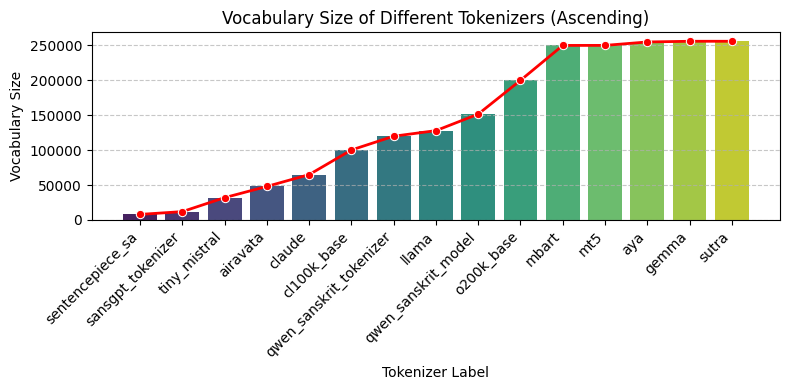

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort meta_df by vocab_size in ascending order
sorted_meta_df = meta_df.sort_values(by='vocab_size', ascending=True)

plt.figure(figsize=(8, 4))
sns.barplot(x='label', y='vocab_size', data=sorted_meta_df, palette='viridis', hue='label', legend=False, order=sorted_meta_df['label'])
# Add a rising red line
sns.lineplot(x='label', y='vocab_size', data=sorted_meta_df, color='red', marker='o', linewidth=2, sort=False)
plt.title('Vocabulary Size of Different Tokenizers (Ascending)')
plt.xlabel('Tokenizer Label')
plt.ylabel('Vocabulary Size')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Evaluation

In [35]:
import pandas as pd
import numpy as np
from google.colab import files
import contextlib
import io
from tqdm.auto import tqdm


def tokenize(data: list, tokenizer, tokenizer_label):
    """
    Tokenizes each sentence individually.
    Returns a DataFrame — one row per sentence.
    """

    records = []

    for sentence in tqdm(data, desc=tokenizer_label):

        if not sentence.strip():
            continue

        # -----------------------------
        # SansGPT
        # -----------------------------
        if type(tokenizer).__name__ == "BPETokenizer":

            with contextlib.redirect_stdout(io.StringIO()):

                tokens = tokenizer.EncodeFromText(
                    sentence,
                    WithoutNewLine=False,
                    SkipFirstChunkInLine=False,
                    Replacements={}
                )

            # token_strings = [
            #     tokenizer.Decode(chunk)
            #     for chunk in tokens
            # ]

            decoded = "".join(
                tokenizer.Decode(chunk)
                for chunk in tokens
            )

        # -----------------------------
        # All other tokenizers
        # -----------------------------
        else:

            tokens = tokenizer.encode(sentence)

            # try:
            #     token_strings = tokenizer.tokenize(sentence)
            #
            # except:
            #     token_strings = [
            #         tokenizer.decode([t])
            #         for t in tokens
            #     ]

            try:
                decoded = tokenizer.decode(
                    tokens,
                    skip_special_tokens=True
                )

            except:
                decoded = tokenizer.decode(tokens)

        # -----------------------------
        # Common calculations
        # -----------------------------

        words = sentence.split()

        num_words = len(words)
        num_tokens = len(tokens)

        num_chars = len(
            sentence.replace(" ", "")
        )

        records.append({

            "sentence": sentence,
            "decoded_sentence": decoded,

            # "tokens": token_strings,

            "similarity": sentence.strip() == decoded.strip(),

            "num_words": num_words,
            "num_tokens": num_tokens,

            # "unique_tokens_count": len(set(tokens)),

            "token_ids": tokens,

            "num_chars": num_chars,

            "fertility": (
                num_tokens / num_words
                if num_words > 0 else None
            ),

            "tokens_per_char": (
                num_tokens / num_chars
                if num_chars > 0 else None
            ),

            "chars_per_token": (
                num_chars / num_tokens
                if num_tokens > 0 else None
            ),

            "tokenizer": tokenizer_label
        })

    df = pd.DataFrame(records)

    return df

## Tokenizer wise results:

In [ ]:
tokenizer_names = []

tokenizers = [

    ("claude", claude),
    ("tiny", tiny),
    ("sutra", sutra),
    ("qwen_sanskrit_model", qwen_sanskrit_model),
    ("qwen_sanskrit_tokenizer", qwen_sanskrit_tokenizer),
    ("mt5", mt5),
    ("mbart", mbart),
    ("airavata" , airavata), # needs login
    ("llama", llama), # needs login # access granted
    ("aya", aya), # needs login
    ("gemma", gemma), # needs login
    ("cl100k_base", gpt_enc),
    ("o200k_base", o200k_enc),
    ("sentencepiece_sa", sp_sa),
    ("sansgpt", Tokenizer)

]

for tok, name in tokenizers:
  print(f"Running {name}")
  temp_df = tokenize(data, name, tok)
  tokenizer_names.append(temp_df)

df = pd.concat(tokenizer_names, ignore_index = True)

Running GPT2Tokenizer(name_or_path='Xenova/claude-tokenizer', vocab_size=65000, model_max_length=200000, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<EOT>', 'eos_token': '<EOT>', 'unk_token': '<EOT>'}, added_tokens_decoder={
	0: AddedToken("<EOT>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<META>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<META_START>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<META_END>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<SOS>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


claude:   0%|          | 0/6148 [00:00<?, ?it/s]

Running TokenizersBackend(name_or_path='openaccess-ai-collective/tiny-mistral', vocab_size=32000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>'}, added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}
)


tiny:   0%|          | 0/6148 [00:00<?, ?it/s]

Running TokenizersBackend(name_or_path='TWO/sutra-mlt256-v2', vocab_size=256001, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	256001: AddedToken("hin_Deva", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	256002: AddedToken("ben_Beng", rstrip=False, lstrip=False, single_word=False, normalized=False, special=Tr

...

o200k_base:   0%|          | 0/6148 [00:00<?, ?it/s]

Running <sentencepiece.SentencePieceProcessor; proxy of <Swig Object of type 'sentencepiece::SentencePieceProcessor *' at 0x79259d828900> >


sentencepiece_sa:   0%|          | 0/6148 [00:00<?, ?it/s]

Running <BPETokenizer.BPETokenizer object at 0x79259d7f04a0>


sansgpt:   0%|          | 0/6148 [00:00<?, ?it/s]

In [ ]:
# uncomment to download a file

"""
filename = f"tokenizer_analysis.xlsx"

df.to_excel(filename, index=False)

files.download(filename)
"""


In [ ]:
df_sp = df[df['tokenizer']=="sentencepiece_sa"]
df_sp = df_sp[df_sp['similarity']== False]
df_sp.head()

In [ ]:
from collections import Counter

bad_chars = Counter()

failures = df_sp[
    df_sp["decoded_sentence"].str.contains("⁇", regex=False)
]

failures[["sentence", "decoded_sentence"]].head(20)

for _, row in failures.iterrows():

    original = row["sentence"]
    decoded = row["decoded_sentence"]

    if "⁇" in decoded:

        idxs = [i for i, c in enumerate(decoded) if c == "⁇"]

        for idx in idxs:
            if idx < len(original):
                bad_chars[original[idx]] += 1

print(bad_chars.most_common(20))

In [ ]:
df['tokenizer'].unique()

In [ ]:
df.head(2)

In [ ]:
df.tail(2)

In [ ]:
df[df['sentence'] == "तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥ "]

### Encoding and Decoding Similarity:

In [ ]:
df['similarity'].value_counts()

In [ ]:
df[df['similarity'] == False][['similarity','tokenizer']].drop_duplicates()

## Summary of Metrices

In [ ]:
summary = (
    df
    .groupby("tokenizer")
    .agg({
        "num_words": "mean",
        "num_tokens": "mean",
        "fertility": "mean",
        "tokens_per_char": "mean",
        "chars_per_token": "mean"
    })
    .sort_values("fertility", ascending=True)
)
summary_round = round(summary, 1)
summary_round

In [ ]:
summary_fertility = (
    df.groupby("tokenizer")["fertility"]
      .agg(["mean", "std", "median", "min", "max"])
      .round(2)
)

summary_fertility

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average fertility per tokenizer
fertility_summary = (
    df.groupby('tokenizer')['fertility']
      .mean()
      .reset_index()
      .sort_values('fertility', ascending=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='tokenizer',
    y='fertility',
    data=fertility_summary,
    palette='viridis'
)

plt.title('Average Fertility by Tokenizer')
plt.xlabel('Tokenizer')
plt.ylabel('Average Fertility (Tokens per Word)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

order = (
    df.groupby("tokenizer")["fertility"]
      .median()
      .sort_values()
      .index
)


# Convert 'tokenizer' column to a categorical type with the specified order
df["tokenizer"] = pd.Categorical(df["tokenizer"], categories=order, ordered=True)

plt.figure(figsize=(15,15))

df.boxplot(
    column="fertility",
    by="tokenizer",
    rot=45,
    showfliers=False
)

plt.ylabel("Fertility")
plt.title("Fertility Distribution by Tokenizer")
plt.suptitle("")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.violinplot(
    data=df,
    x="tokenizer",
    y="fertility",
    cut=0
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

tokenizers = df["tokenizer"].unique()

fig, axes = plt.subplots(
    len(tokenizers),
    1,
    figsize=(12, 3*len(tokenizers)),
    sharex=True
)

for ax, tok in zip(axes, tokenizers):

    subset = df[df["tokenizer"] == tok]

    subset["fertility"].plot(
        kind="kde",
        ax=ax
    )

    ax.set_title(tok)

plt.tight_layout()
plt.show()

In [ ]:
# !pip install joypy
import joypy
import matplotlib.pyplot as plt

joypy.joyplot(
    df,
    by="tokenizer",
    column="fertility",
    figsize=(12,8)
)

plt.show()

# Vedic Corpus

In [ ]:
# !pip install datasets

In [ ]:
from datasets import load_dataset
vedic = load_dataset("shunyasea/vedic-sanskrit")

In [ ]:
print(vedic)

In [ ]:
vedic = vedic["test"]["text"]

In [ ]:
vedic[:5]

In [ ]:
print(len(vedic))

In [ ]:
# size of dataset, one wants to set
import random

random.seed(42)
n = 5000
vedic = random.sample(vedic, n)

print(len(vedic))

In [ ]:
vedic = clean_text(vedic)

In [ ]:
corpus_statistics(vedic)

In [ ]:
tokenizer_names = []

tokenizers = [

    ("claude", claude),
    ("tiny", tiny),
    ("sutra", sutra),
    ("qwen_sanskrit_model", qwen_sanskrit_model),
    ("qwen_sanskrit_tokenizer", qwen_sanskrit_tokenizer),
    ("mt5", mt5),
    ("mbart", mbart),
    ("airavata" , airavata), # needs login
    ("llama", llama), # needs login # access granted
    ("aya", aya), # needs login
    ("gemma", gemma), # needs login
    ("cl100k_base", gpt_enc),
    ("o200k_base", o200k_enc),
    ("sentencepiece_sa", sp_sa),
    ("sansgpt", Tokenizer)



]

for tok, name in tokenizers:
  temp_df = tokenize(vedic, name, tok)
  tokenizer_names.append(temp_df)

df = pd.concat(tokenizer_names, ignore_index = True)

In [ ]:
df.tail()

In [ ]:
summary = (
    df
    .groupby("tokenizer")
    .agg({
        "num_words": "mean",
        "num_tokens": "mean",
        "fertility": "mean",
        "tokens_per_char": "mean",
        "chars_per_token": "mean"
    })
    .sort_values("fertility", ascending=True)
)
summary_round = round(summary, 1)
summary_round

In [ ]:
df[df['similarity'] == False][['similarity','tokenizer']].drop_duplicates()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average fertility per tokenizer
fertility_summary = (
    df.groupby('tokenizer')['fertility']
      .mean()
      .reset_index()
      .sort_values('fertility', ascending=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='tokenizer',
    y='fertility',
    data=fertility_summary,
    palette='viridis'
)

plt.title('Average Fertility by Tokenizer')
plt.xlabel('Tokenizer')
plt.ylabel('Average Fertility (Tokens per Word)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()